# Activation Functions

## Begin with two switches and one small puzzle

Imagine an indicator connected to two switches. We want it to light when exactly one switch is on. If both switches are off, it stays dark. If both are on, it also stays dark.

This rule is called **XOR**, short for exclusive or. We can describe it with a tiny table:

| First switch | Second switch | Indicator |
| --- | --- | --- |
| Off | Off | Off |
| Off | On | On |
| On | Off | On |
| On | On | Off |

Using zero for off and one for on places the four cases at the corners of a square. The positive cases occupy opposite corners. No single straight line can separate those two corners from the other two.

A neuron that makes a decision from one weighted sum and a threshold therefore cannot express this rule on the raw switch inputs. Adding more computation sounds promising, but the kind of computation matters.

This lesson explains the small change that lets a network develop more flexible responses: the **activation function**. We will first see why it is needed, then inspect actual numbers and curves. The [code companion](03_Activation_Functions.ipynb) performs the same demonstrations in PyTorch.

## Start with the problem this lesson solves

Suppose an alarm should sound when exactly one of two switches is on. This is XOR: inputs 01 and 10 should produce one, while 00 and 11 should produce zero. One straight threshold boundary cannot separate these opposite corners.

Adding layers of weighted sums alone does not fix this: composing affine functions still gives an affine function. An activation supplies a nonlinear transformation, allowing later layers to combine pieces of a decision rule.

## Calculate how an activation makes XOR possible

Let $s=x_1+x_2$. Choose two hidden units:

$$h_1=\operatorname{ReLU}(s),\qquad h_2=\operatorname{ReLU}(s-1),$$

where $\operatorname{ReLU}(a)=\max(0,a)$. Choose output $\hat y=h_1-2h_2$. These weights are deliberately constructed to expose the mechanism.

| Input | $s$ | $h_1=\max(0,s)$ | $h_2=\max(0,s-1)$ | $\hat y=h_1-2h_2$ |
| --- | --- | --- | --- | --- |
| $(0,0)$ | $0+0=0$ | 0 | 0 | $0-2(0)=0$ |
| $(0,1)$ | $0+1=1$ | 1 | 0 | $1-2(0)=1$ |
| $(1,0)$ | $1+0=1$ | 1 | 0 | $1-2(0)=1$ |
| $(1,1)$ | $1+1=2$ | 2 | 1 | $2-2(1)=0$ |

The first hidden unit counts total activity. The second activates only beyond a total of one. Subtracting twice that extra activity turns the response back down when both switches are on. A single straight response cannot rise and then fall this way.

**Remove the nonlinear operation and see what breaks.** Without ReLU, $h_1=s$ and $h_2=s-1$, so $\hat y=s-2(s-1)=2-s$. For 00 this gives two rather than zero. More generally, $W_2(W_1x+b_1)+b_2=(W_2W_1)x+(W_2b_1+b_2)$: adding an affine layer merely changes the effective weights and bias.

**Why the activation also affects learning.** At score two, ReLU returns two and its local slope is one: an upstream gradient of $0.3$ remains $0.3\times1=0.3$. At score minus two, ReLU returns zero and its slope is zero: the same upstream gradient becomes zero on that path. Sigmoid at two is approximately $0.880797$, with slope $p(1-p)\approx0.104994$, so that gradient becomes about $0.031498$. Multiplying many small slopes can weaken the learning signal. At the ReLU corner zero, PyTorch uses derivative zero.

## Why the choice belongs to the task

Hidden activations let an ANN express interactions that weighted sums alone cannot. Their slopes also determine how readily gradients pass backward. ReLU is simple and often useful, but some units may receive zero gradient on negative scores.

Output transformations have a different job: sigmoid can describe one binary probability, softmax distributes probability among mutually exclusive classes, and a linear output can predict an unrestricted numeric value. The exact XOR construction above demonstrates representational ability; it does not prove that random initialization and training will always discover those weights.

## Locate the activation in the calculation

A neuron first combines its inputs using weights and a bias. The result is a score, usually written as $z$. An activation function then turns that score into the value passed onward.

$$a=\phi(z).$$

Here $a$ means the output. The symbol $\phi$, pronounced “phi,” is just a name for the chosen function. The expression says “apply that function to the score.”

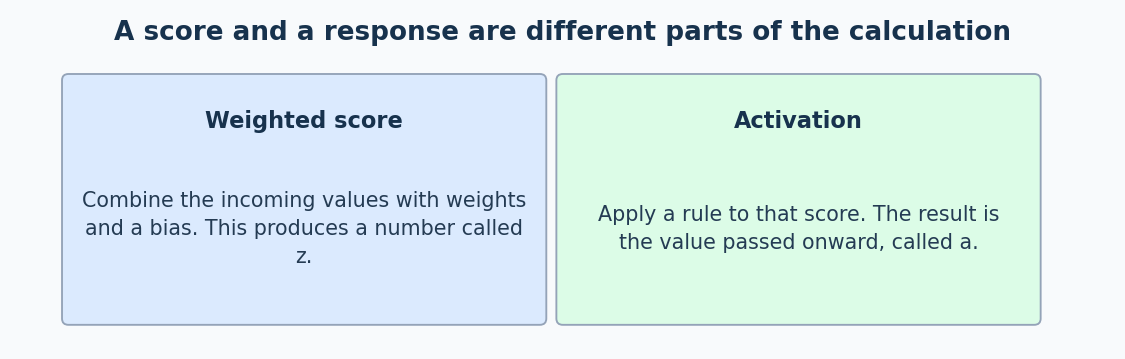

For example, a score of minus two could remain minus two, become zero, or become a small positive value, depending on the chosen rule. We will see why these alternatives are useful.

The word **activation** can refer to the function or to its output values. The context tells us which meaning is intended. It does not always mean a yes-or-no switch.

## See why stacking weighted sums does not solve the problem

Suppose the first stage takes an input $x$ and calculates $h=2x+1$. A second stage calculates $y=3h-4$. The letters $h$ and $y$ name the intermediate value and final output.

For input two, the first stage gives five and the second gives eleven. But we can obtain the same answer without two stages:

$$y=3(2x+1)-4=6x-1.$$

| Route | Calculation when $x=2$ | Output |
| --- | --- | --- |
| Two stages | $h=2(2)+1=5$, then $y=3(5)-4$ | 11 |
| One combined stage | $y=6(2)-1$ | 11 |

Multiplication followed by an offset is called an **affine** calculation. Chaining affine calculations produces another affine calculation, even when there are many inputs and layers.

The extra stages have changed the bookkeeping, but they have not created a response with different behavior in different regions. We need something that prevents this collapse.

## Insert a bend between the stages

Consider a rule that keeps positive values but replaces negative ones with zero. This is **ReLU**, the rectified linear unit:

$$\operatorname{ReLU}(z)=\max(0,z).$$

The symbol $\max$ means choose the larger value. Now let the hidden value be $h=\max(0,2x+1)$, keeping the output rule $y=3h-4$.

| Input $x$ | Hidden score $2x+1$ | After ReLU $h$ | Output $3h-4$ |
| --- | --- | --- | --- |
| -1 | -1 | 0 | -4 |
| 0 | 1 | 1 | -1 |
| 2 | 5 | 5 | 11 |

For all inputs at or below $-0.5$, the hidden score is nonpositive, so the output stays at $-4$. Above that point, the output follows $6x-1$.

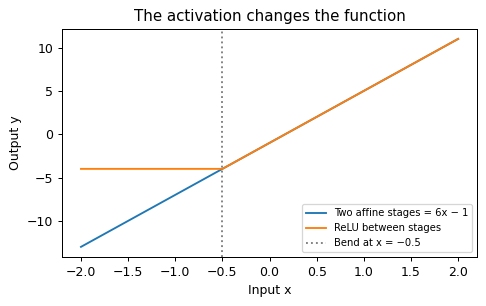

One line cannot describe the whole response. This is the useful meaning of **nonlinearity** here: the calculation can behave differently across input regions. ReLU is straight within each region, but its complete response has a bend.

## Compare response rules using the same scores

Before introducing more formulas, pass the same values through several functions:

| Incoming score | Identity | Sigmoid | Tanh | ReLU |
| --- | --- | --- | --- | --- |
| -2 | -2 | 0.119 | -0.964 | 0 |
| 0 | 0 | 0.500 | 0 | 0 |
| 2 | 2 | 0.881 | 0.964 | 2 |

**Identity** leaves the score unchanged. **Sigmoid** compresses it between zero and one. **Tanh** compresses it between minus one and one. ReLU removes the negative part and keeps the positive part.

These functions act **elementwise**: each score is processed separately. A table of scores stays the same size after the transformation. Only its values change.

In these examples, the activation functions have no learned parameters of their own. The scores entering them depend on learned weights and biases. This distinction explains how a fixed rule such as ReLU can still be part of an adjustable model.

## Sigmoid gives a gradual, bounded response

Sometimes we want an output that stays between zero and one. A sigmoid provides that range without making an abrupt jump:

$$\sigma(z)=\frac{1}{1+e^{-z}}.$$

$\sigma$ names the sigmoid function, $z$ is the incoming score, and $e\approx2.718$ is the base of the natural exponential. For score two, follow the arithmetic:

| Operation | Result |
| --- | --- |
| Negate the score | -2 |
| Calculate $e^{-2}$ | About 0.135 |
| Add one | About 1.135 |
| Divide one by the result | About 0.881 |

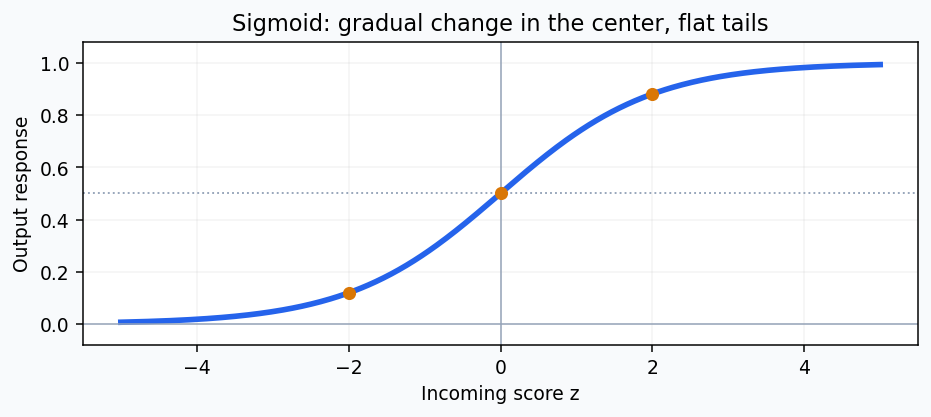

At zero, the output is exactly one half. Very negative scores approach zero; very positive scores approach one. Sigmoid can therefore support a binary probability estimate in an appropriately trained classifier. It can also act as a **gate**: a multiplier controlling how much of another value passes through.

A number in this range is not automatically a trustworthy probability. Suitable training and evaluation must establish that interpretation.

## A curve also tells us how sensitive the response is

In the middle of the sigmoid curve, a small score change noticeably changes the output. Near the flat tails, a similar score change does very little. This flattening is called **saturation**.

For example, changing the score from zero to $0.1$ changes sigmoid by about $0.025$. Changing it from eight to $8.1$ changes the output by only about $0.000032$.

A **derivative** describes this local sensitivity: how much output changes for a tiny change in input. Visually, it is the curve's local slope.

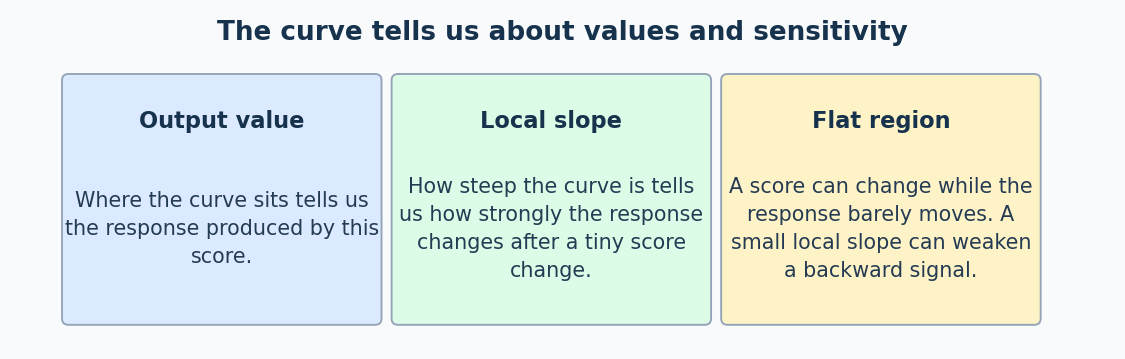

Sigmoid's derivative is $\sigma'(z)=\sigma(z)(1-\sigma(z))$. The prime means derivative with respect to the score. At zero, the slope is $0.5(1-0.5)=0.25$. Near either tail, it approaches zero.

The slope matters because a learning signal passing backward through the function is multiplied by that local sensitivity. A very small factor can make the signal much weaker.

## Tanh keeps a signed response

Sigmoid never returns a negative number. Sometimes an intermediate value should indicate both direction and strength. **Tanh**, short for hyperbolic tangent, maps negative scores to negative outputs and positive scores to positive outputs, while remaining between minus one and one.

$$\tanh(z)=\frac{e^z-e^{-z}}{e^z+e^{-z}}.$$

The exponential terms have the same meaning as in sigmoid. At score one, the numerator is approximately $2.718-0.368=2.350$, and the denominator is $2.718+0.368=3.086$. Their ratio is about $0.762$.

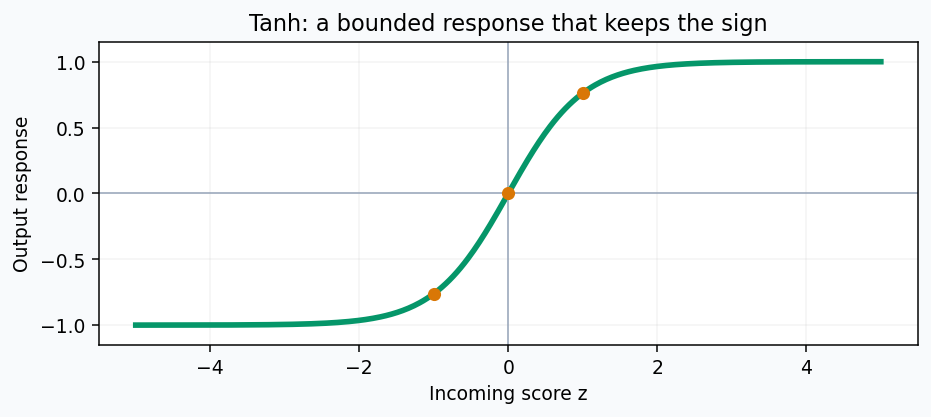

At score minus one, the output is about $-0.762$; at zero, it is zero. The function is symmetric around zero, but this does not guarantee that a particular collection of outputs has mean zero.

Tanh's derivative is $1-\tanh^2(z)$, where the square applies to the output. Its slope is one at zero and becomes small in the tails. Tanh therefore still has saturation-related limitations.

## ReLU keeps the positive side open

ReLU's positive side has slope one: increasing a positive score by a small amount increases its output by the same amount. Unlike sigmoid and tanh, this side does not flatten. Its output is also unbounded above.

On the negative side, the output and slope are both zero. If a unit stays negative for all relevant training examples, ordinary gradient information through that unit can stay zero. This is called the **dying ReLU** problem. A single zero response does not mean a unit is dead.

At exactly zero, the two sides meet at a corner, so an ordinary derivative does not exist. PyTorch uses zero as its gradient convention at that point. The presence of this corner does not prevent gradient-based learning elsewhere.

A **leaky ReLU** retains a small negative-side slope. With a chosen slope $\alpha=0.1$, a negative score is multiplied by one tenth instead of being set to zero.

| Score | ReLU | Leaky ReLU with $\alpha=0.1$ |
| --- | --- | --- |
| -2 | 0 | -0.2 |
| 0 | 0 | 0 |
| 2 | 2 | 2 |

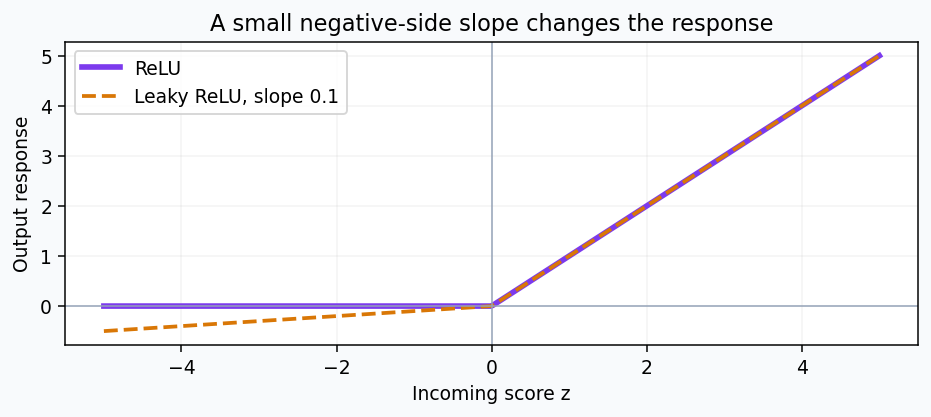

The symbol $\alpha$ names the chosen slope. Giving the negative side a path for sensitivity can help, but it does not guarantee that the whole network will learn well.

## Recognize a smooth alternative without losing the main idea

The companion also includes **GELU**, the Gaussian error linear unit. It multiplies a score by a smoothly changing factor rather than clipping all negative values to zero.

Its rule is $z\Phi(z)$. Here $\Phi(z)$ is the probability that a standard normal random variable—a bell-shaped distribution with mean zero and variance one—is at most $z$.

| Score | Scaling factor $\Phi(z)$ | GELU output |
| --- | --- | --- |
| -1 | About 0.159 | About -0.159 |
| 0 | 0.5 | 0 |
| 1 | About 0.841 | About 0.841 |

This probability is a factor in the formula, not a classification probability predicted by the network. GELU's full output can be negative or exceed one.

The combined picture below gathers the functions and their slopes. Solid curves show output values; dashed curves show local slopes. ReLU and leaky ReLU's displayed gradient at exactly zero follows a software convention.

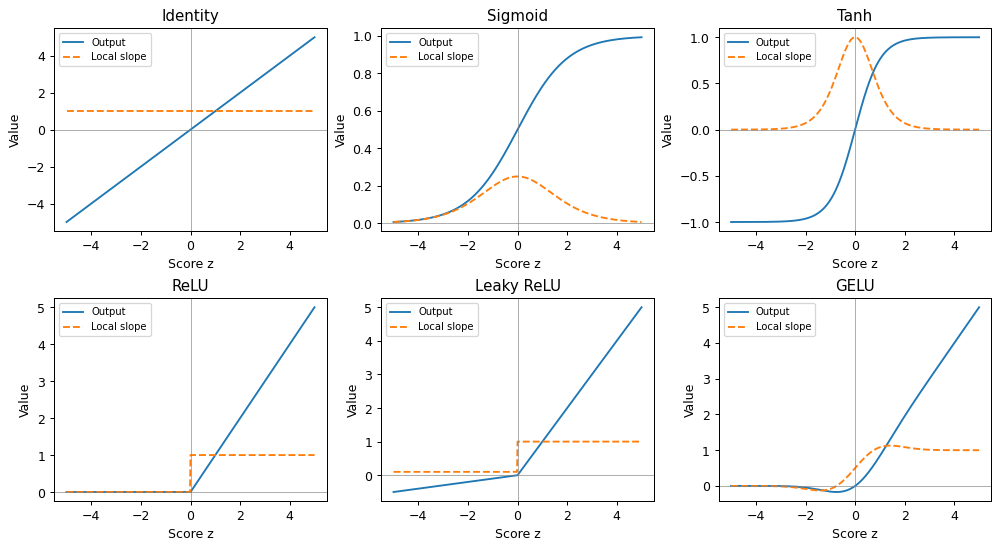

## Return to the switch puzzle

We can now build the XOR response using two intermediate calculations. Let $x_1$ and $x_2$ be the switch values. Each hidden unit measures one direction of disagreement:

$$h_1=\operatorname{ReLU}(x_1-x_2),\qquad h_2=\operatorname{ReLU}(x_2-x_1).$$

Add the hidden outputs to obtain score $s=h_1+h_2$.

For switches $(1,0)$, the signed differences are one and minus one. ReLU keeps the one and removes the negative value. Their sum is one, so the indicator turns on.

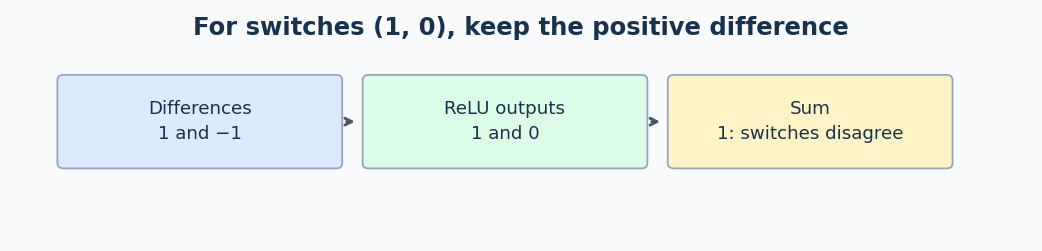

| Switches | Signed differences | After ReLU | Sum |
| --- | --- | --- | --- |
| $(0,0)$ | $(0,0)$ | $(0,0)$ | 0 |
| $(0,1)$ | $(-1,1)$ | $(0,1)$ | 1 |
| $(1,0)$ | $(1,-1)$ | $(1,0)$ | 1 |
| $(1,1)$ | $(0,0)$ | $(0,0)$ | 0 |

Without ReLU, the differences always cancel: $(x_1-x_2)+(x_2-x_1)=0$. The activation prevents this cancellation by keeping different contributions in different input regions.

Thresholding the sum above one half gives the required labels. For continuous inputs, this construction computes absolute difference, not a calibrated probability. We chose its parameters ourselves, so it demonstrates what the network can express, not how training discovers it.

## Follow sensitivity through several stages

A **gradient** collects derivatives of an output or loss with respect to inputs or parameters. When computations form a chain, local sensitivities multiply along that chain.

For $h=f(x)$ and $y=g(h)$, the chain rule is $dy/dx=(dy/dh)(dh/dx)$. It says that the sensitivity of the whole path combines the sensitivity of each stage.

| Number of factors | Product if each factor is one quarter |
| --- | --- |
| One | 0.25 |
| Two | 0.0625 |
| Four | 0.00390625 |

Repeated small factors can weaken an earlier layer's learning signal, contributing to **vanishing gradients**. This table isolates one mechanism. Real networks also multiply by weights and combine multiple paths. Large weights can amplify signals, and a ReLU path can still shut off or shrink for other reasons.

PyTorch's **autograd** records supported calculations and computes their derivatives. The companion measures a simple chain's input sensitivity without training a network. Such a demonstration does not establish the full behavior of every deep model.

## Choose the final transformation from the question being asked

Hidden activations help build useful intermediate descriptions. Output transformations give the final values a meaning suited to the task.

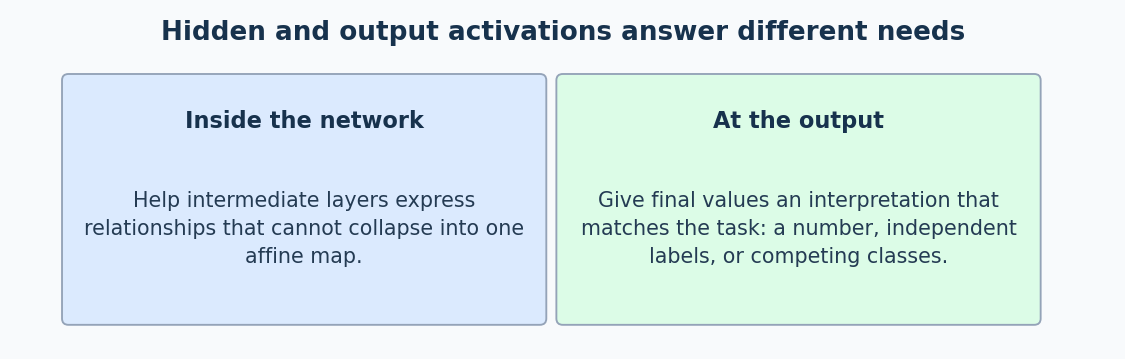

| Task | Common output treatment | Reason |
| --- | --- | --- |
| Predict an unrestricted number | Keep a raw output | The answer may be any real value |
| Predict one binary label | Apply sigmoid for probability display | One score becomes a value between zero and one |
| Predict several labels that may all apply | A sigmoid for each label | Each probability is treated independently |
| Choose exactly one class | Apply softmax for probability display | Classes compete for a total probability of one |

A **logit** is a raw classification score before probability conversion. A vector of scores by itself does not tell us whether labels are independent or competing; that depends on the task.

## See how softmax makes classes compete

Suppose three class scores are $(2,1,0)$. **Softmax** exponentiates them, then divides each result by their total:

| Class | Score | Exponential | Share of the total |
| --- | --- | --- | --- |
| A | 2 | About 7.389 | About 0.665 |
| B | 1 | About 2.718 | About 0.245 |
| C | 0 | 1 | About 0.090 |

The total exponential value is about $11.107$. Dividing by this shared total makes the probabilities sum to one.

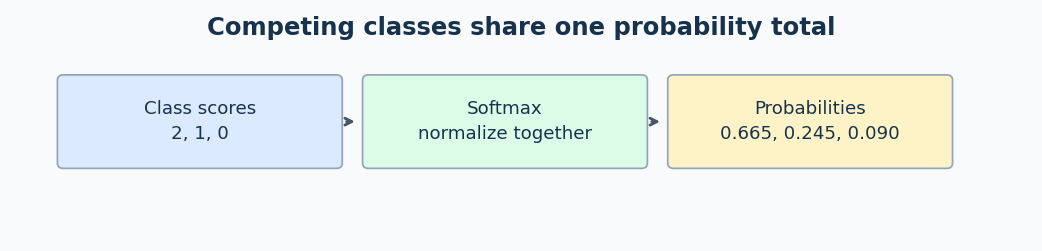

The general rule is $p_k=e^{z_k}/\sum_{j=1}^{K}e^{z_j}$. $K$ counts the classes, $z_k$ is one class's score, $p_k$ is its resulting probability, and $\sum$ adds all class contributions.

Changing one score changes the shared denominator, so it affects every probability. Sigmoid applied separately does not create that competition.

For numerical stability, subtract the largest score before exponentiating. Scores $(0,-1,-2)$ give the same probabilities as $(2,1,0)$ because the shared exponential factor cancels. With a batch shaped `(examples, classes)`, normalize across classes in each row, not across examples.

## Keep the implementation consistent with the meaning

PyTorch's `BCEWithLogitsLoss` for binary targets and `CrossEntropyLoss` for the usual class-index setup already perform the relevant stable probability-related calculations internally. They expect raw logits. Applying sigmoid or softmax before them changes the intended calculation.

Use those transformations separately when probabilities need to be displayed. A correctly bounded output still needs evaluation before its confidence can be trusted.

| Common misunderstanding | More accurate interpretation |
| --- | --- |
| Any activation is an on/off switch | Many produce graded, continuous responses |
| ReLU always prevents vanishing gradients | Weights and other paths also affect sensitivity |
| A zero ReLU value means the unit is dead | Persistent inactivity across relevant inputs is the concern |
| Softmax is appropriate for any group of labels | It represents competing classes, not independently true labels |
| One activation is best everywhere | The architecture, input scale, initialization, and task matter |

The central idea is that an activation changes both the response a network can express and the sensitivities passing through it. The curves, arithmetic, and switch construction give us ways to see those effects directly.

## Alternatives to ReLU

PReLU uses $f(z)=z$ for $z\ge0$ and $az$ otherwise, where $a$ is learned. ELU uses $\alpha(e^z-1)$ on the negative side and approaches $-\alpha$. SELU is a scaled ELU with prescribed constants and works best with its matching initialization and AlphaDropout assumptions. Swish, called SiLU when $\beta=1$, is $z\sigma(\beta z)$ and changes smoothly through zero. These functions preserve different amounts of negative signal and have different compute and saturation behavior.